In [424]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import lifelines
sns.set_style('white')

In [108]:
BATCH_SIZE = 100_000
SEED = 37
SAMPLE_PROPORTION = 0.001

In [3]:
member_batches = []
max_index = 0

for batch in pd.read_csv('../data/members_v3.csv', chunksize = BATCH_SIZE):
    member_batches.append(batch.sample(frac = SAMPLE_PROPORTION, random_state = SEED))
    if max(batch.index) + 1 > max_index:
        max_index = max(batch.index) + 1

sample_members = pd.concat(member_batches, ignore_index = True)
member_ids = set(sample_members['msno'])

print(f'{len(sample_members): ,} out of {max_index: ,} members selected.')
print()
print(sample_members.head())
print()
print(sample_members.info())

 6,769 out of  6,769,473 members selected.

                                           msno  city  bd  gender  \
0  59LT0TXKCMT0x8lBV6lihO8CvTZ9z5Sb9UsypwfC6Uk=     1   0     NaN   
1  +9WO11eKjgcyXUN4ewrT4Q00zTKY/fHbZgYaxZsSDt8=     1   0     NaN   
2  6P/ta5JtN8UDFiuHI2ELWXLaRUsgN97Zj63QAMWLycQ=     1   0     NaN   
3  0g6qJ7am8vecp54eFV7I0ceLy8yzHWJA0a32aNZM6YU=     1  21  female   
4  LVZhPn7ds6KtnZ1GPMHV4DFhCuYAiQtf4QucKYL2d9A=     1   0     NaN   

   registered_via  registration_init_time  
0               4                20161202  
1               9                20120208  
2               4                20161206  
3               3                20150414  
4               9                20150919  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769 entries, 0 to 6768
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   msno                    6769 non-null   object
 1   city     

In [418]:
sample_members2 = sample_members.copy()

sample_members2[['city', 'registered_via']] = sample_members2[['city', 'registered_via']].astype('object')
sample_members2['registration_init_time'] = pd.to_datetime(sample_members2['registration_init_time'], format = '%Y%m%d')

print(sample_members2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769 entries, 0 to 6768
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    6769 non-null   object        
 1   city                    6769 non-null   object        
 2   bd                      6769 non-null   int64         
 3   gender                  2325 non-null   object        
 4   registered_via          6769 non-null   object        
 5   registration_init_time  6769 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 317.4+ KB
None


In [24]:
sample_members3 = sample_members2.copy()
print('proportion of invalid ages:')
print(((sample_members3['bd'] <= 0) | (sample_members3['bd'] > 111)).mean())
print()
sample_members3['bd'] = [None if x <= 0 or x > 111 else x for x in sample_members3['bd']]
print('proportion of missing \'bd\' and \'gender\':')
print(((sample_members3['bd'].isna()) & (sample_members3['gender'].isna())).mean())
print()
print('proportion of missing \'bd\' only:')
print(((sample_members3['bd'].isna()) & (~ sample_members3['gender'].isna())).mean())
print()
print('proportion of missing \'gender\' only:')
print(((sample_members3['gender'].isna()) & (~ sample_members3['bd'].isna())).mean())

proportion of invalid ages:
0.6692273600236371

proportion of missing 'bd' and 'gender':
0.6497266952282464

proportion of missing 'bd' only:
0.01950066479539075

proportion of missing 'gender' only:
0.006795686216575565


In [50]:
sample_members4 = sample_members3.copy()
sample_members4['is_complete_bd_and_gender'] = (~ sample_members4['gender'].isna()) & (~ sample_members4['bd'].isna())
sample_members4 = sample_members4.drop(columns = ['bd', 'gender'])

print(sample_members4.info())
print()
print('proportion of registrations within observation window:')
print((sample_members4['registration_init_time'] >= pd.to_datetime(20150101, format = '%Y%m%d')).mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769 entries, 0 to 6768
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   msno                       6769 non-null   object        
 1   city                       6769 non-null   object        
 2   registered_via             6769 non-null   object        
 3   registration_init_time     6769 non-null   datetime64[ns]
 4   is_complete_bd_and_gender  6769 non-null   bool          
dtypes: bool(1), datetime64[ns](1), object(3)
memory usage: 218.3+ KB
None

proportion of registrations within observation window:
0.6407150243758309


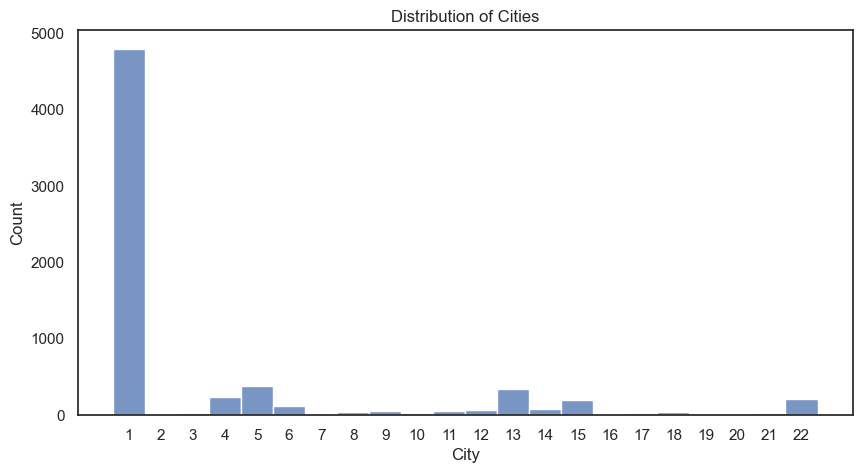

In [429]:
plt.figure(figsize = (10, 5))
plt.title('Distribution of Cities')
sns.histplot(sample_members4['city'], discrete = True)
plt.xticks(range(max(sample_members4['city']) + 1)[1:])
plt.xlabel('City')
plt.show()

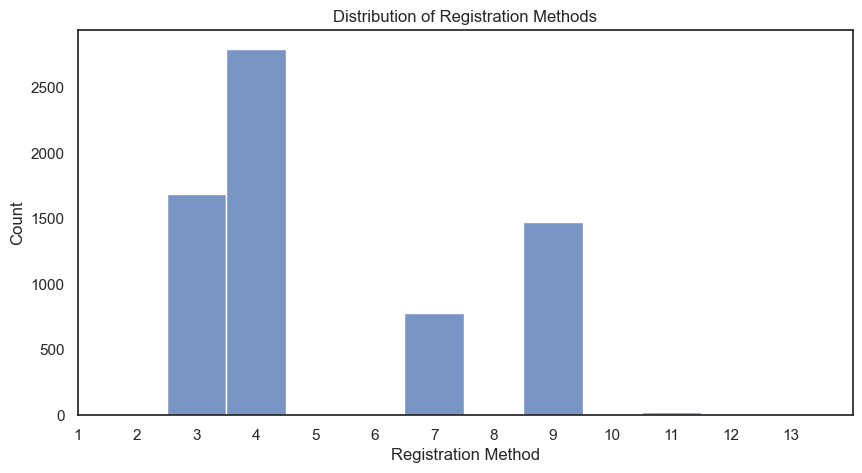

In [430]:
plt.figure(figsize = (10, 5))
plt.title('Distribution of Registration Methods')
sns.histplot(sample_members4['registered_via'], discrete = True)
plt.xticks(range(max(sample_members4['registered_via']) + 1)[1:])
plt.xlabel('Registration Method')
plt.show()

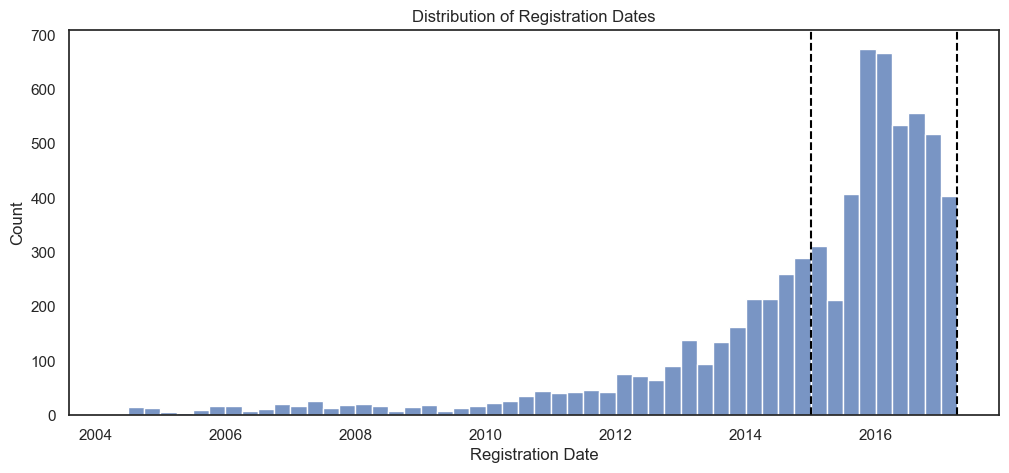

In [431]:
plt.figure(figsize = (12, 5))
plt.title('Distribution of Registration Dates')
daterange = pd.date_range(start = sample_members4['registration_init_time'].min(), end = sample_members4['registration_init_time'].max(), freq='3MS')
sns.histplot(sample_members4['registration_init_time'], bins = mpl.dates.date2num(daterange))
plt.axvline(pd.to_datetime(20150101, format = '%Y%m%d'), color = 'black', linestyle = 'dashed')
plt.axvline(pd.to_datetime(20170331, format = '%Y%m%d'), color = 'black', linestyle = 'dashed')
plt.xlabel('Registration Date')
plt.show()

In [54]:
transaction_batches = []

max_index_total = 0
for csv in ['../data/transactions.csv', '../data/transactions_v2.csv']:
    max_index = 0
    for batch in pd.read_csv(csv, chunksize = BATCH_SIZE):
        transaction_batches.append(batch[batch['msno'].isin(member_ids)])
        if max(batch.index) + 1 > max_index:
            max_index = max(batch.index) + 1
    max_index_total += max_index
    
sample_transactions = pd.concat(transaction_batches, ignore_index = True)

print(f'{len(sample_transactions): ,} out of {max_index_total: ,} transactions selected.')
print()
print(sample_transactions.head())
print()
print(sample_transactions.info())

 19,801 out of  22,978,755 transactions selected.

                                           msno  payment_method_id  \
0  9kW4ORgM/7pZ3O2i4/ACTkeyjt1keEpBRmcWiYEZHiU=                 41   
1  wcXslluldERi48gljH+9o9KgXgYsCt5ih8+i3EXUNIE=                 34   
2  mCQIOwBybuLG6L88zC65GiNd5jihPflNq03KWRYbA+c=                 40   
3  qaT4OYJ+gEbriiBlR29k4BUJeszVX8VxapTeUuO0xa4=                 40   
4  +6K9UdokGth8QGWvwpnmc4LIeLs1GDQUadRwli4D4ac=                 39   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                 30              149                 149              1   
1                 30              149                 149              1   
2                 30              149                 149              1   
3                 30              149                 149              1   
4                 30              149                 149              1   

   transaction_date  membership_expire_date  is_cancel  
0          201

In [111]:
sample_transactions2 = sample_transactions.copy()

sample_transactions2['payment_method_id'] = sample_transactions2['payment_method_id'].astype('object')
for column in ['transaction_date', 'membership_expire_date']:
    sample_transactions2[column] = pd.to_datetime(sample_transactions2[column], format = '%Y%m%d')
sample_transactions2[['is_auto_renew', 'is_cancel']] = sample_transactions2[['is_auto_renew', 'is_cancel']].astype('boolean')

print(sample_transactions2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19801 entries, 0 to 19800
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    19801 non-null  object        
 1   payment_method_id       19801 non-null  object        
 2   payment_plan_days       19801 non-null  int64         
 3   plan_list_price         19801 non-null  int64         
 4   actual_amount_paid      19801 non-null  int64         
 5   is_auto_renew           19801 non-null  boolean       
 6   transaction_date        19801 non-null  datetime64[ns]
 7   membership_expire_date  19801 non-null  datetime64[ns]
 8   is_cancel               19801 non-null  boolean       
dtypes: boolean(2), datetime64[ns](2), int64(3), object(2)
memory usage: 1.1+ MB
None


In [117]:
sample_transactions3 = sample_transactions2.copy()
print((sample_transactions3['transaction_date'] <= sample_transactions3['membership_expire_date']).mean())
sample_transactions3['membership_expire_date'] = np.where(sample_transactions3['is_cancel'], sample_transactions3['transaction_date'], sample_transactions3['membership_expire_date'])

print(sample_transactions3.head())

0.9925256300186859
                                           msno payment_method_id  \
0  9kW4ORgM/7pZ3O2i4/ACTkeyjt1keEpBRmcWiYEZHiU=                41   
1  wcXslluldERi48gljH+9o9KgXgYsCt5ih8+i3EXUNIE=                34   
2  mCQIOwBybuLG6L88zC65GiNd5jihPflNq03KWRYbA+c=                40   
3  qaT4OYJ+gEbriiBlR29k4BUJeszVX8VxapTeUuO0xa4=                40   
4  +6K9UdokGth8QGWvwpnmc4LIeLs1GDQUadRwli4D4ac=                39   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                 30              149                 149           True   
1                 30              149                 149           True   
2                 30              149                 149           True   
3                 30              149                 149           True   
4                 30              149                 149           True   

  transaction_date membership_expire_date  is_cancel  
0       2016-01-06             2016-02-06      False  

In [229]:
OBS_START = pd.to_datetime(20150101, format = '%Y%m%d')
OBS_END = pd.to_datetime(20170331, format = '%Y%m%d')
GRACE_PERIOD = pd.to_timedelta(30, unit = 'days')

sample_transactions4 = sample_transactions3.copy()\
    .drop(columns = ['payment_method_id', 'payment_plan_days', 'plan_list_price', 'is_auto_renew', 'is_cancel'])\
    .sort_values(by = ['msno', 'transaction_date'])


sample_transactions4['end_date'] = [min(x, OBS_END) for x in sample_transactions4['membership_expire_date']]
sample_transactions4['is_last_obs'] = sample_transactions4.groupby('msno')['transaction_date'].transform(lambda x: x == x.max())
sample_transactions4['event'] = (
    (
        (sample_transactions4['end_date'] + grace_period < sample_transactions4['transaction_date'].shift(-1)) & 
        (sample_transactions4['msno'] == sample_transactions4['msno'].shift(-1))
    ) |
    (
        (sample_transactions4['is_last_obs']) & 
        (sample_transactions4['end_date'] + grace_period < OBS_END)
    )
)

sample_transactions4

,msno,actual_amount_paid,transaction_date,membership_expire_date,end_date,is_last_obs,event
1567,++M4G6SSlhINyHbCMt5KVjPdbDAZkaJ0a51FF8lGr04=,99,2015-11-17,2015-12-17,2015-12-17,False,False
1463,++M4G6SSlhINyHbCMt5KVjPdbDAZkaJ0a51FF8lGr04=,99,2015-12-17,2016-01-17,2016-01-17,False,False
1095,++M4G6SSlhINyHbCMt5KVjPdbDAZkaJ0a51FF8lGr04=,99,2016-01-17,2016-02-17,2016-02-17,False,False
3319,++M4G6SSlhINyHbCMt5KVjPdbDAZkaJ0a51FF8lGr04=,99,2016-02-17,2016-03-17,2016-03-17,False,False
4410,++M4G6SSlhINyHbCMt5KVjPdbDAZkaJ0a51FF8lGr04=,99,2016-03-17,2016-04-17,2016-04-17,False,False
...,...,...,...,...,...,...,...
6837,zw4da6HOWVlvhRIDQRkW0BsU4EwRpM1yLJ6NwfX9u8c=,149,2016-01-20,2016-02-19,2016-02-19,False,False
12577,zw4da6HOWVlvhRIDQRkW0BsU4EwRpM1yLJ6NwfX9u8c=,149,2016-02-20,2016-03-19,2016-03-19,False,False
5476,zw4da6HOWVlvhRIDQRkW0BsU4EwRpM1yLJ6NwfX9u8c=,149,2016-03-20,2016-04-19,2016-04-19,False,False
11554,zw4da6HOWVlvhRIDQRkW0BsU4EwRpM1yLJ6NwfX9u8c=,149,2016-04-20,2016-05-19,2016-05-19,False,False


In [303]:
survival = pd.merge(sample_members4, sample_transactions4, how = 'inner')

survival['start'] = (survival['transaction_date'] - survival['registration_init_time']).dt.days + 1
survival['end'] = (survival['end_date'] - survival['registration_init_time']).dt.days + 1
survival['event_num'] = survival.groupby('msno')['event'].cumsum()
survival['tenure'] = survival.groupby('msno')['event_num'].shift(1, fill_value = 0) + 1

survival = survival\
    .groupby(['msno',
              'tenure',
              'city', 
              'is_complete_bd_and_gender', 
              'registered_via'], 
             dropna = False)\
    .agg({
        'actual_amount_paid': 'sum',
        'start': 'min',
        'end': 'max',
        'event': 'last'
    })    

survival = survival[(survival['start'] < survival['end'])].reset_index()
print(survival.head())

                                           msno  tenure  city  \
0  ++M4G6SSlhINyHbCMt5KVjPdbDAZkaJ0a51FF8lGr04=       1     1   
1  ++bQ/m6G+0XALmzX6fVXZmJkTBL95sxh166sI/METug=       1    13   
2  +0soPX8fELBq0t5QfRLsWsEBQN1UOld6K+3MMeK4BWM=       1     4   
3  +1B1xTeP8fVBaB5xaLx1Dtl37SFX6XMd/gMAXEIfAJI=       1    13   
4  +1HAj1TASYQYoWbbFirjfVXB3RrXwdBmZGZURSuXFNo=       1    13   

   is_complete_bd_and_gender  registered_via  actual_amount_paid  start   end  \
0                      False               7                1683      1   501   
1                       True               9                3576   3328  3769   
2                       True               3                1370    391   831   
3                       True               9                3576    289   903   
4                      False               3                3387    618  1231   

   event  
0  False  
1  False  
2   True  
3  False  
4  False  


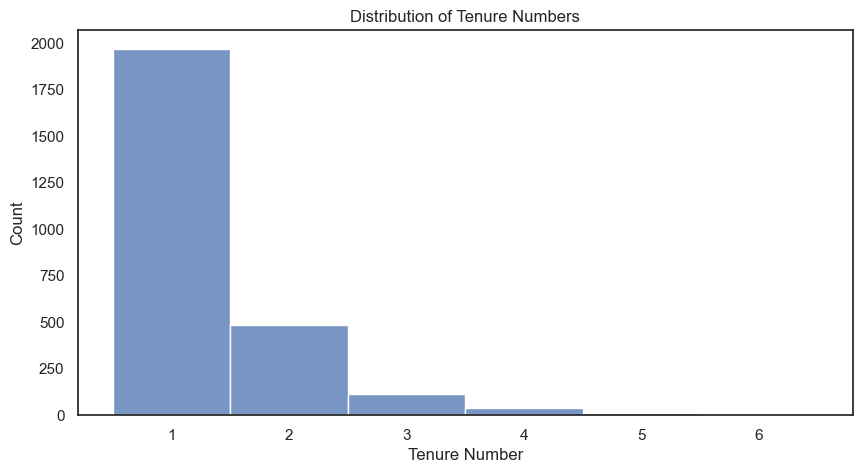

In [456]:
plt.figure(figsize = (10, 5))
plt.title('Distribution of Tenure Numbers')
sns.histplot(survival['tenure'], discrete = True)
plt.xlabel('Tenure Number')
plt.show()

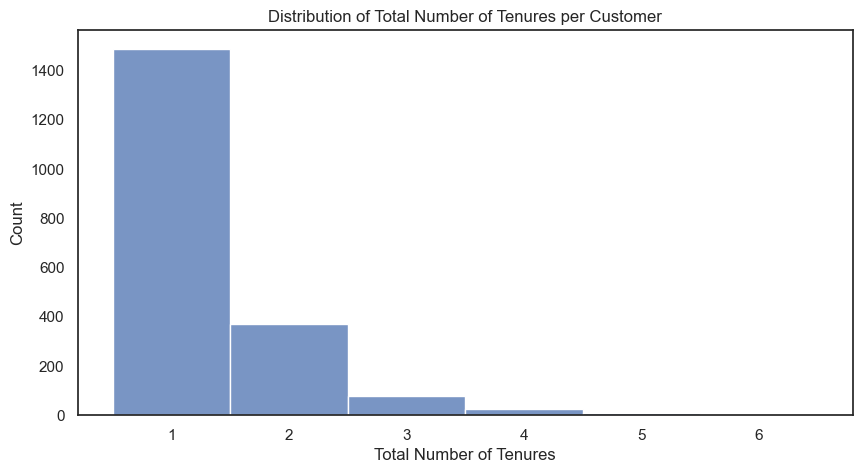

In [459]:
plt.figure(figsize = (10, 5))
tenure = survival.copy().groupby('msno').agg({'tenure': 'max'})
plt.title('Distribution of Total Number of Tenures per Customer')
sns.histplot(tenure['tenure'], discrete = True)
plt.xlabel('Total Number of Tenures')
plt.show()

In [475]:
print(f"average tenure value: {sum(survival['actual_amount_paid']) / len(survival.copy()[['msno', 'tenure']].drop_duplicates()):.0f}")
print(f"average customer value: {sum(survival['actual_amount_paid']) / len(survival['msno'].unique()):.0f}")

average tenure value: 1199
average customer value: 1595


instances: 2631
median tenure length: 190 days


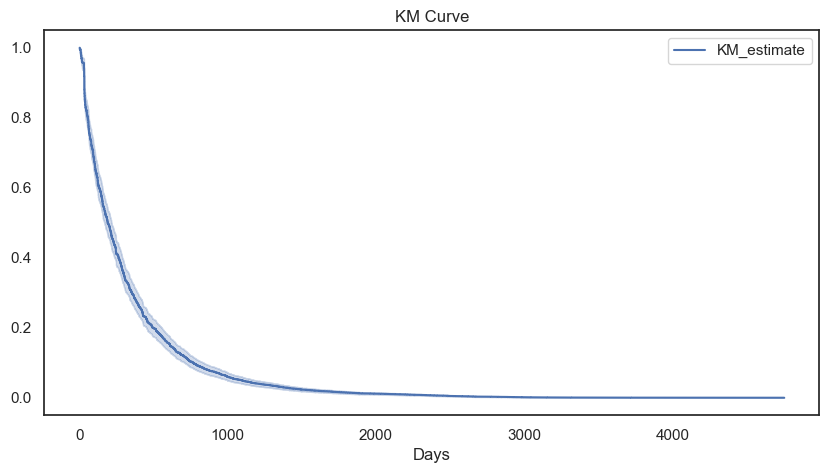

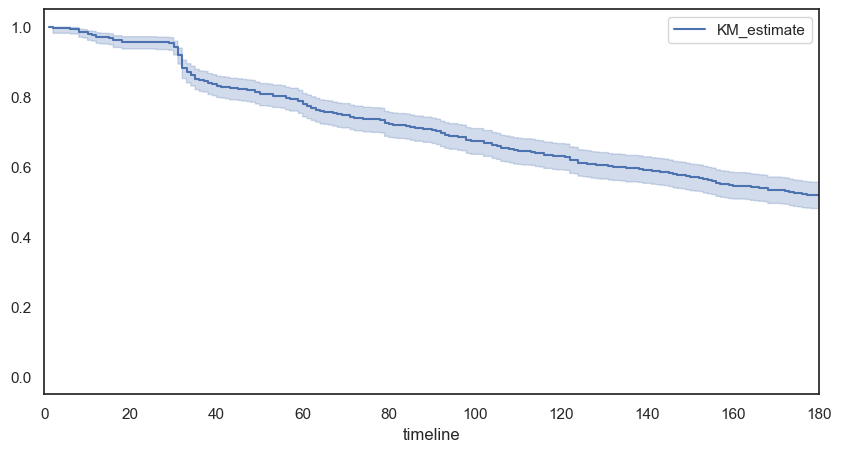

In [510]:
plt.figure(figsize = (10, 5))
plt.title('KM Curve')
kmf = lifelines.KaplanMeierFitter()
kmf.fit(survival['end'], survival['event'], entry = survival['start'])
print(f"instances: {len(survival)}")
print(f"median tenure length: {kmf.median_survival_time_:.0f} days")
kmf.plot()
plt.xlabel('Days')
plt.show()

plt.figure(figsize = (10, 5))
kmf.plot()
plt.xlim(0, 180)
plt.show()

instances: 427
median tenure length: 644 days


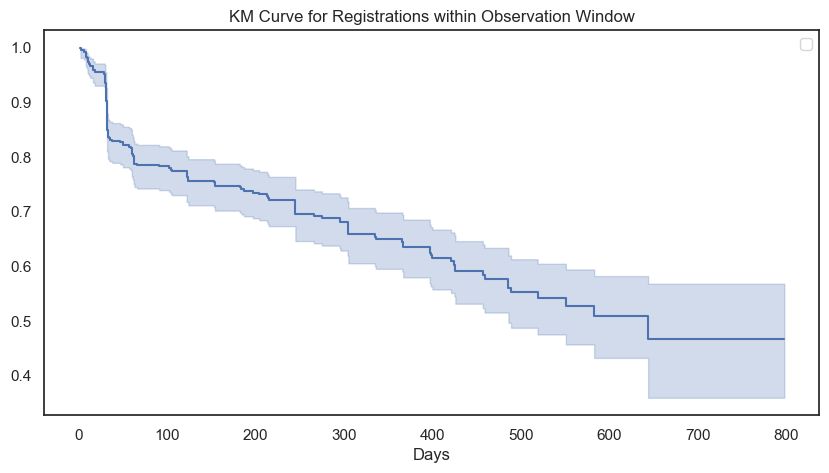

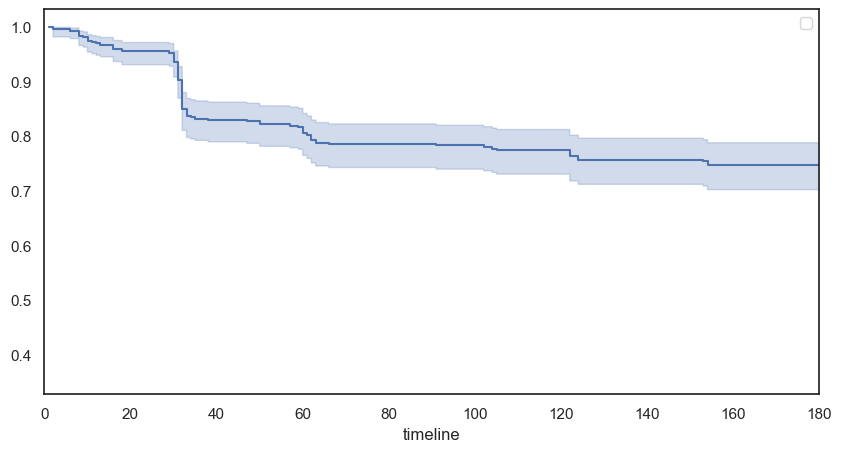

In [518]:
plt.figure(figsize = (10, 5))
plt.title('KM Curve for Registrations within Observation Window')
kmf = lifelines.KaplanMeierFitter()
s = survival[survival['start'] == 1]
kmf.fit(s['end'], s['event'], entry = s['start'])
print(f"instances: {len(s)}")
print(f"median tenure length: {kmf.median_survival_time_:.0f} days")
kmf.plot()
plt.xlabel('Days')
plt.legend('')
plt.show()

plt.figure(figsize = (10, 5))
kmf.plot()
plt.xlim(0, 180)
plt.legend('')
plt.show()

median tenure length for completed profiles: 180.0 days
median tenure length for incomplete profiles: 205.0 days


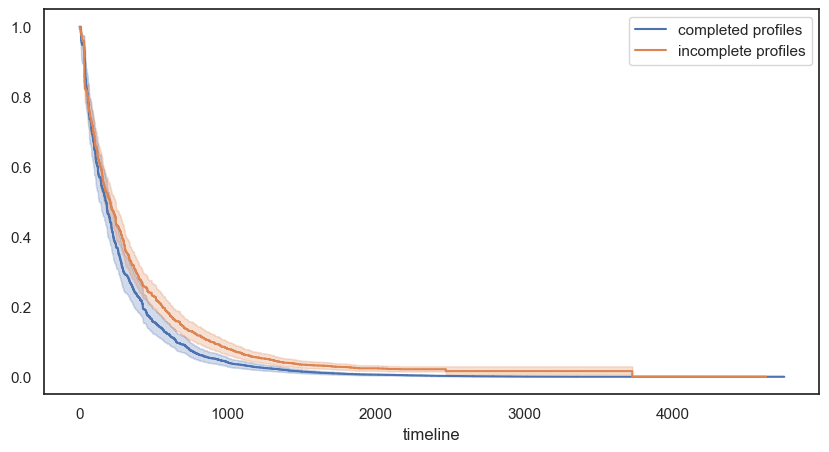

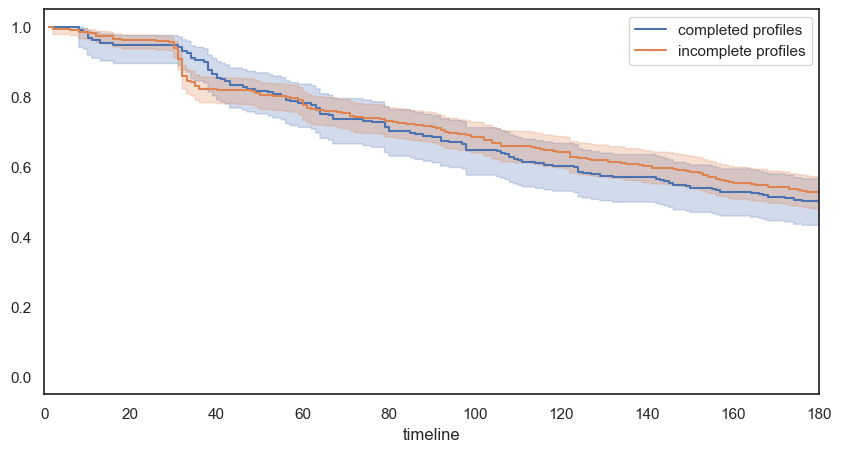

In [519]:
plt.figure(figsize = (10, 5))
for x in [True, False]:
    kmf = lifelines.KaplanMeierFitter()
    s = survival[survival['is_complete_bd_and_gender'] == x]
    if x: l = 'completed profiles'
    else: l = 'incomplete profiles'
    kmf.fit(s['end'], s['event'], entry = s['start'], label = l)
    print(f"median tenure length for {l}: {kmf.median_survival_time_} days")
    kmf.plot()
plt.show()

plt.figure(figsize = (10, 5))
for x in [True, False]:
    kmf = lifelines.KaplanMeierFitter()
    s = survival[survival['is_complete_bd_and_gender'] == x]
    if x: l = 'completed profiles'
    else: l = 'incomplete profiles'
    kmf.fit(s['end'], s['event'], entry = s['start'], label = l)
    kmf.plot()
plt.xlim(0, 180)
plt.show()

median tenure length for city 1: 168.0 days
median tenure length for other cities: 231.0 days


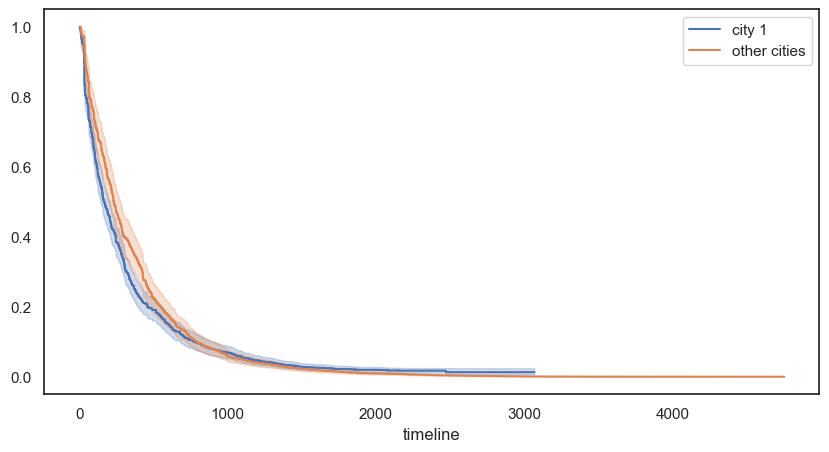

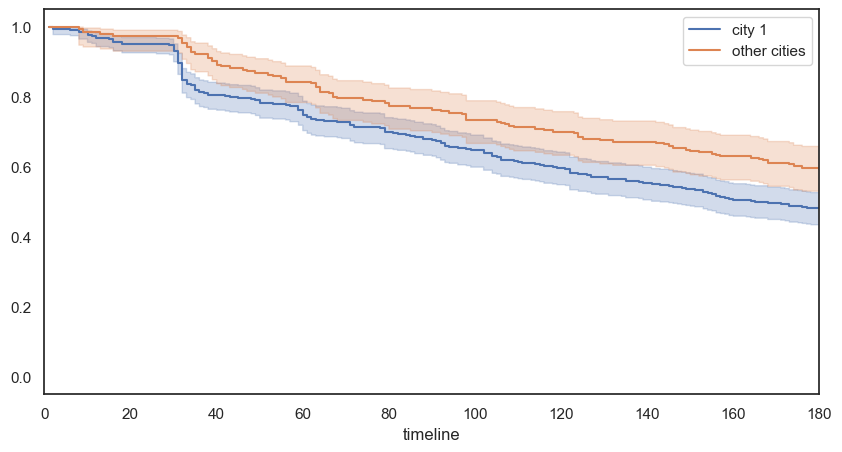

In [523]:
plt.figure(figsize = (10, 5))
for x in [True, False]:
    kmf = lifelines.KaplanMeierFitter()
    s = survival[(survival['city'] == 1) == x]
    if x: l = 'city 1'
    else: l = 'other cities'
    kmf.fit(s['end'], s['event'], entry = s['start'], label = l)
    print(f"median tenure length for {l}: {kmf.median_survival_time_} days")
    kmf.plot()
plt.show()

plt.figure(figsize = (10, 5))
for x in [True, False]:
    kmf = lifelines.KaplanMeierFitter()
    s = survival[(survival['city'] == 1) == x]
    if x: l = 'city 1'
    else: l = 'other cities'
    kmf.fit(s['end'], s['event'], entry = s['start'], label = l)
    kmf.plot()
plt.xlim(0, 180)
plt.show()